In [ ]:

import os
import warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import pearsonr, spearmanr
import time
import json

print(" Core libraries loaded")

XGBOOST_AVAILABLE = False
LIGHTGBM_AVAILABLE = False

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
    print(" XGBoost available")
except ImportError:
    print(" XGBoost not available")

try:
    from lightgbm import LGBMRegressor
    LIGHTGBM_AVAILABLE = True
    print(" LightGBM available")
except ImportError:
    print(" LightGBM not available")

try:
    import optuna
    OPTUNA_AVAILABLE = True
    print(" Optuna available")
except ImportError:
    OPTUNA_AVAILABLE = False
    print(" Optuna not available")

def _safe_spearman(y_true, y_pred):
    try:
        v = spearmanr(y_true, y_pred).correlation
        return float(v) if np.isfinite(v) else 0.0
    except Exception:
        return 0.0

print("\n" + "="*80)
print(" COMPLETE PIPELINE READY")
print("="*80)

 Core libraries loaded
 XGBoost available
 LightGBM available
 Optuna available

 COMPLETE PIPELINE READY


In [ ]:

train = pd.read_csv('c:/projects/mitsui/train.csv')
test = pd.read_csv('c:/projects/mitsui/test.csv')
train_labels = pd.read_csv('c:/projects/mitsui/train_labels.csv')
target_pairs = pd.read_csv('c:/projects/mitsui/target_pairs.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Train labels shape: {train_labels.shape}")
print(f"Target pairs shape: {target_pairs.shape}")

Train shape: (1961, 558)
Test shape: (134, 559)
Train labels shape: (1961, 425)
Target pairs shape: (424, 3)


In [ ]:

train_interp = train.copy()
train_interp = train_interp.interpolate(method='linear', limit_direction='both', axis=0)
print(f" Interpolation complete. Remaining NaNs: {train_interp.isnull().sum().sum()}")

 Interpolation complete. Remaining NaNs: 0


In [ ]:

def create_features(df, target_pair):
    """Create features for a given target pair or single asset."""
    fe = df.copy()
    if 'date_id' in fe.columns:
        fe = fe.set_index('date_id')
    
    helpers = [c for c in fe.columns if c.startswith('FX_USD') or c.startswith('US_TREASURY_YIELD_')]

    def calc_rsi(series, period=14):
        delta = series.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
        rs = gain / loss
        return 100 - (100 / (1 + rs))

    def calc_macd(series, fast=12, slow=26, signal=9):
        exp1 = series.ewm(span=fast, adjust=False).mean()
        exp2 = series.ewm(span=slow, adjust=False).mean()
        macd = exp1 - exp2
        signal_line = macd.ewm(span=signal, adjust=False).mean()
        return macd, signal_line

    def calc_bb(series, window=20, num_std=2):
        roll_mean = series.rolling(window).mean()
        roll_std = series.rolling(window).std()
        upper = roll_mean + (roll_std * num_std)
        lower = roll_mean - (roll_std * num_std)
        return upper, lower

    if ' - ' in target_pair:
        # PAIR TARGET
        parts = target_pair.split(' - ')
        A, B = parts[0], parts[1]
        
        fe['spread_t'] = fe[A] - fe[B]
        for k in [1, 2, 3, 5, 10]:
            fe[f'spread_lag{k}'] = fe['spread_t'].shift(k)
        
        fe[f'{A}_ret'] = fe[A].pct_change()
        fe[f'{B}_ret'] = fe[B].pct_change()
        for k in [1, 2, 3, 5]:
            fe[f'{A}_ret_lag{k}'] = fe[f'{A}_ret'].shift(k)
            fe[f'{B}_ret_lag{k}'] = fe[f'{B}_ret'].shift(k)
        
        for w in [20, 60]:
            roll_mean = fe['spread_t'].rolling(w).mean()
            roll_std = fe['spread_t'].rolling(w).std()
            fe[f'spread_zscore_{w}'] = (fe['spread_t'] - roll_mean) / roll_std

        fe['spread_rsi'] = calc_rsi(fe['spread_t'])
        fe['spread_macd'], fe['spread_macd_sig'] = calc_macd(fe['spread_t'])
        fe['spread_macd_hist'] = fe['spread_macd'] - fe['spread_macd_sig']
        bb_upper, bb_lower = calc_bb(fe['spread_t'])
        fe['spread_bb_width'] = (bb_upper - bb_lower) / fe['spread_t']
        fe['spread_bb_pos'] = (fe['spread_t'] - bb_lower) / (bb_upper - bb_lower)

        for w in [3, 5, 10]:
            fe[f'{A}_roll{w}'] = fe[A].rolling(w).mean()
            fe[f'{B}_roll{w}'] = fe[B].rolling(w).mean()
            fe[f'spread_roll{w}'] = fe['spread_t'].rolling(w).mean()
            fe[f'spread_vol{w}']  = fe['spread_t'].rolling(w).std()
        
        relevant_cols = {col for col in fe.columns if col.startswith(('spread_', A, B))}
        
    else:
        # SINGLE ASSET
        asset = target_pair
        for k in [1, 2, 3, 5, 10]:
            fe[f'{asset}_lag{k}'] = fe[asset].shift(k)
        fe[f'{asset}_ret'] = fe[asset].pct_change()
        for k in [1, 2, 3, 5]:
            fe[f'{asset}_ret_lag{k}'] = fe[f'{asset}_ret'].shift(k)
            
        fe[f'{asset}_rsi'] = calc_rsi(fe[asset])
        fe[f'{asset}_macd'], fe[f'{asset}_macd_sig'] = calc_macd(fe[asset])
        bb_upper, bb_lower = calc_bb(fe[asset])
        fe[f'{asset}_bb_pos'] = (fe[asset] - bb_lower) / (bb_upper - bb_lower)
        for w in [3, 5, 10]:
            fe[f'{asset}_roll{w}'] = fe[asset].rolling(w).mean()
            fe[f'{asset}_vol{w}'] = fe[asset].rolling(w).std()
            
        relevant_cols = {col for col in fe.columns if col.startswith(asset)}

    final_cols = list(relevant_cols) + helpers
    fe_pair = fe[final_cols].copy()
    fe_pair = fe_pair.replace([np.inf, -np.inf], np.nan).dropna()
    fe_pair.reset_index(inplace=True)
    return fe_pair

print(" Feature engineering function ready")

 Feature engineering function ready


In [ ]:

RUN_MODE = "OPTIMIZED"  

if RUN_MODE == "BASELINE":
    RUN_OPTIMIZATION = False
    N_TRIALS = 0
    OUTPUT_PREFIX = "baseline_"
    print("="*60)
    print(" BASELINE RUN - Using Default Parameters")
    print("="*60)
    
elif RUN_MODE == "OPTIMIZED":
    RUN_OPTIMIZATION = True
    N_TRIALS = 10
    OUTPUT_PREFIX = "optimized_"
    print("="*60)
    print(" OPTIMIZED RUN - Hyperparameter Tuning Enabled")
    print(f"Trials per model: {N_TRIALS}")
    print("="*60)
else:
    raise ValueError("RUN_MODE must be 'BASELINE' or 'OPTIMIZED'")

DEMO_MODE = False
USE_GPU = True
MAX_TARGETS = None

print(f"Demo Mode: {DEMO_MODE}")
print(f"GPU Enabled: {USE_GPU}")
print(f"Max Targets: {MAX_TARGETS if MAX_TARGETS else 'ALL'}")
print(f"Output Prefix: {OUTPUT_PREFIX}")
print("="*60)

# Prepare labels
long_labels = train_labels.melt(id_vars='date_id', var_name='target', value_name='label')
labels_merged = long_labels.merge(target_pairs, on='target', how='left').dropna(subset=['label'])

# Load cached params
best_params = {}
if RUN_MODE == "OPTIMIZED":
    try:
        with open('best_hyperparameters.json', 'r') as f:
            best_params = json.load(f)
        print(f" Loaded cached hyperparameters for {len(best_params)} targets")
    except FileNotFoundError:
        print(" No cached hyperparameters found")

# Select targets
if DEMO_MODE:
    example_pair = 'LME_CA_Close - LME_ZS_Close'
    demo_targets = target_pairs[target_pairs['pair'] == example_pair]['target'].head(1).tolist()
    single_assets = target_pairs[~target_pairs['pair'].str.contains(' - ', na=False)]
    if not single_assets.empty:
        demo_targets.append(single_assets['target'].iloc[0])
    targets_to_run = demo_targets
    print(f" DEMO MODE: {len(targets_to_run)} targets")
else:
    targets_to_run = target_pairs['target'].unique()
    if MAX_TARGETS:
        targets_to_run = targets_to_run[:MAX_TARGETS]
    print(f" Running on {len(targets_to_run)} targets")

 OPTIMIZED RUN - Hyperparameter Tuning Enabled
Trials per model: 10
Demo Mode: False
GPU Enabled: True
Max Targets: ALL
Output Prefix: optimized_
 No cached hyperparameters found
 Running on 424 targets


In [ ]:

models_config = {}


models_config['Ridge'] = {
    'class': Ridge,
    'default_params': {'alpha': 1.0, 'random_state': 42},
    'optimize': False
}


models_config['Lasso'] = {
    'class': Lasso,
    'default_params': {'alpha': 1.0, 'random_state': 42, 'max_iter': 5000},
    'optimize': False
}


models_config['RandomForest'] = {
    'class': RandomForestRegressor,
    'default_params': {
        'n_estimators': 100,
        'max_depth': 10,
        'random_state': 42,
        'n_jobs': -1
    },
    'optimize': False
}


models_config['ElasticNet'] = {
    'class': ElasticNet,
    'default_params': {'alpha': 1.0, 'l1_ratio': 0.5, 'random_state': 42, 'max_iter': 5000},
    'optimize': True
}


if XGBOOST_AVAILABLE:
    xgb_params = {
        'n_estimators': 200,
        'learning_rate': 0.05,
        'max_depth': 6,
        'random_state': 42,
        'n_jobs': -1
    }
    if USE_GPU:
        xgb_params['tree_method'] = 'hist'
        xgb_params['device'] = 'cuda'
    
    models_config['XGBoost'] = {
        'class': XGBRegressor,
        'default_params': xgb_params,
        'optimize': True
    }


if LIGHTGBM_AVAILABLE:
    lgb_params = {
        'n_estimators': 200,
        'learning_rate': 0.05,
        'num_leaves': 31,
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    if USE_GPU:
        lgb_params['device'] = 'gpu'
    
    models_config['LightGBM'] = {
        'class': LGBMRegressor,
        'default_params': lgb_params,
        'optimize': True
    }

print(f"\n Configured {len(models_config)} models:")
print("\n BASELINE MODELS (no optimization):")
for name, cfg in models_config.items():
    if not cfg['optimize']:
        print(f"   {name}")

print("\n ADVANCED MODELS (will optimize in OPTIMIZED mode):")
for name, cfg in models_config.items():
    if cfg['optimize']:
        opt_status = "WILL OPTIMIZE" if RUN_OPTIMIZATION else "DEFAULT PARAMS"
        print(f"   {name}: {opt_status}")


 Configured 6 models:

 BASELINE MODELS (no optimization):
   Ridge
   Lasso
   RandomForest

 ADVANCED MODELS (will optimize in OPTIMIZED mode):
   ElasticNet: WILL OPTIMIZE
   XGBoost: WILL OPTIMIZE
   LightGBM: WILL OPTIMIZE


In [ ]:

import os
if os.path.exists('best_hyperparameters.json'):
    os.remove('best_hyperparameters.json')
    print(" Deleted cached hyperparameters - will optimize fresh")

In [ ]:


results = []
optimization_log = []
total_targets = len(targets_to_run)
start_overall = time.time()

for idx, target_id in enumerate(targets_to_run, 1):
    target_info = target_pairs[target_pairs['target'] == target_id].iloc[0]
    pair_name = target_info['pair']
    lag = target_info['lag']
    
    print(f"\n{'='*60}")
    print(f"[{idx}/{total_targets}] Target: {target_id}")
    print(f"Pair: {pair_name} | Lag: {lag}")
    print(f"{'='*60}")
    
    
    try:
        features_df = create_features(train_interp, pair_name)
        print(f" Features: {features_df.shape}")
    except Exception as e:
        print(f" Feature engineering failed: {e}")
        continue
    

    tgt_labels = labels_merged[labels_merged['target'] == target_id][['date_id', 'label']]
    data = features_df.merge(tgt_labels, on='date_id', how='inner').sort_values('date_id')
    
    if data.empty:
        print(" No overlapping data")
        continue
 
    split_idx = int(len(data) * 0.8)
    train_data = data.iloc[:split_idx]
    val_data = data.iloc[split_idx:]
    
    X_train = train_data.drop(columns=['date_id', 'label'])
    y_train = train_data['label']
    X_val = val_data.drop(columns=['date_id', 'label'])
    y_val = val_data['label']
    
    print(f"Train: {len(X_train)} | Val: {len(X_val)}")
    

    for model_name, config in models_config.items():
        print(f"  {model_name:15s}: ", end="")
        
        should_optimize = (config['optimize'] and 
                          RUN_OPTIMIZATION and 
                          OPTUNA_AVAILABLE and
                          model_name in ['XGBoost', 'LightGBM', 'ElasticNet'])
        
       
        if target_id in best_params and model_name in best_params[target_id]:
            final_params = best_params[target_id][model_name]
            print("(cached) ", end="")
            
        elif should_optimize:
            print("optimizing... ", end="")
            
            import optuna
            optuna.logging.set_verbosity(optuna.logging.WARNING)
            
         
            def objective(trial):
               
                if model_name == 'ElasticNet':
                    params = {
                        'alpha': trial.suggest_float('alpha', 0.001, 10.0, log=True),
                        'l1_ratio': trial.suggest_float('l1_ratio', 0.0, 1.0),
                        'random_state': 42,
                        'max_iter': 5000
                    }

                elif model_name == 'XGBoost':
                    params = {
                        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
                        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
                        'max_depth': trial.suggest_int('max_depth', 3, 10),
                        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
                        'gamma': trial.suggest_float('gamma', 0, 0.5),
                        'random_state': 42,
                        'n_jobs': -1
                    }
                    if USE_GPU:
                        params['tree_method'] = 'hist'
                        params['device'] = 'cuda'
                
             
                elif model_name == 'LightGBM':
                    params = {
                        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
                        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
                        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
                        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
                        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1.0),
                        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1.0),
                        'random_state': 42,
                        'n_jobs': -1,
                        'verbose': -1
                    }
                    if USE_GPU:
                        params['device'] = 'gpu'
                
                else:
                   
                    params = config['default_params'].copy()
                
      
                tscv = TimeSeriesSplit(n_splits=3)
                scores = []
                
                for tr_idx, va_idx in tscv.split(X_train):
                    Xt, Xv = X_train.iloc[tr_idx], X_train.iloc[va_idx]
                    yt, yv = y_train.iloc[tr_idx], y_train.iloc[va_idx]
                    
                    mdl = config['class'](**params)
                    mdl.fit(Xt, yt)
                    p = mdl.predict(Xv)
                    scores.append(_safe_spearman(yv, p))
                
                return np.mean(scores)
            
           
            try:
                study = optuna.create_study(direction='maximize')
                study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
                
                final_params = study.best_params.copy()
                final_params['random_state'] = 42
                
            
                if model_name == 'ElasticNet':
                    final_params['max_iter'] = 5000
                    
                elif model_name == 'XGBoost':
                    final_params['n_jobs'] = -1
                    if USE_GPU:
                        final_params['tree_method'] = 'hist'
                        final_params['device'] = 'cuda'
                        
                elif model_name == 'LightGBM':
                    final_params['n_jobs'] = -1
                    final_params['verbose'] = -1
                    if USE_GPU:
                        final_params['device'] = 'gpu'
                
               
                if target_id not in best_params:
                    best_params[target_id] = {}
                best_params[target_id][model_name] = final_params
                
                
                optimization_log.append({
                    'Target': target_id,
                    'Model': model_name,
                    'Best_CV_Spearman': study.best_value,
                    'N_Trials': N_TRIALS
                })
                
            except Exception as opt_error:
              
                print(f"opt_failed, using defaults... ", end="")
                final_params = config['default_params'].copy()
            
        else:
          
            final_params = config['default_params'].copy()
            print("(default) ", end="")
        
        try:
            start_time = time.time()
            
            model = config['class'](**final_params)
            model.fit(X_train, y_train)
            
           
            preds = model.predict(X_val)
            
           
            rmse = np.sqrt(mean_squared_error(y_val, preds))
            mae = mean_absolute_error(y_val, preds)
            r2 = r2_score(y_val, preds)
            spearman = _safe_spearman(y_val, preds)
            elapsed = time.time() - start_time
            
            print(f"RMSE: {rmse:.5f} | Spearman: {spearman:.5f} | {elapsed:.1f}s")
            
          
            results.append({
                'Target': target_id,
                'Pair': pair_name,
                'Lag': lag,
                'Model': model_name,
                'RMSE': rmse,
                'MAE': mae,
                'R2': r2,
                'Spearman': spearman,
                'Train_Time': elapsed,
                'Optimized': should_optimize,
                'Run_Mode': RUN_MODE
            })
            
        except Exception as train_error:
            print(f" FAILED: {str(train_error)[:80]}")
    
  
    elapsed_total = time.time() - start_overall
    avg_time_per_target = elapsed_total / idx
    remaining_targets = total_targets - idx
    eta_seconds = avg_time_per_target * remaining_targets
    eta_minutes = eta_seconds / 60
    
    print(f"  Progress: {idx}/{total_targets} | Elapsed: {elapsed_total/60:.1f}min | ETA: {eta_minutes:.1f}min")


print("\n" + "="*60)
print(" TRAINING COMPLETE!")
print("="*60)
total_time = time.time() - start_overall
print(f"Total time: {total_time/60:.1f} minutes")
print(f"Results collected: {len(results)}")


[1/424] Target: target_0
Pair: US_Stock_VT_adj_close | Lag: 1
 Features: (1942, 24)
Train: 1448 | Val: 362
  Ridge          : (default) RMSE: 0.01071 | Spearman: 0.01272 | 0.0s
  Lasso          : (default) RMSE: 0.00985 | Spearman: 0.00000 | 0.0s
  RandomForest   : (default) RMSE: 0.01172 | Spearman: -0.00459 | 0.3s
  ElasticNet     : optimizing... RMSE: 0.00989 | Spearman: 0.05706 | 0.0s
  XGBoost        : optimizing... RMSE: 0.00991 | Spearman: 0.03638 | 0.2s
  LightGBM       : optimizing... RMSE: 0.01010 | Spearman: -0.02463 | 1.3s
  Progress: 1/424 | Elapsed: 0.4min | ETA: 148.9min

[2/424] Target: target_1
Pair: LME_PB_Close - US_Stock_VT_adj_close | Lag: 1
 Features: (1902, 41)
Train: 1383 | Val: 346
  Ridge          : (default) RMSE: 0.01416 | Spearman: 0.07248 | 0.0s
  Lasso          : (default) RMSE: 0.01364 | Spearman: 0.00000 | 0.0s
  RandomForest   : (default) RMSE: 0.01435 | Spearman: 0.07163 | 0.4s
  ElasticNet     : optimizing... RMSE: 0.01362 | Spearman: 0.11749 | 0.0s

[W 2025-11-30 01:43:47,752] Trial 0 failed with parameters: {'n_estimators': 176, 'learning_rate': 0.02599897042421235, 'max_depth': 9, 'subsample': 0.6052321853892856, 'colsample_bytree': 0.816629080503262, 'min_child_weight': 7, 'gamma': 0.2905290999711049} because of the following error: AttributeError("'DataFrame' object has no attribute 'dtype'").
Traceback (most recent call last):
  File "C:\Users\sujay\AppData\Roaming\Python\Python313\site-packages\optuna\study\_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\sujay\AppData\Local\Temp\ipykernel_35672\1259136102.py", line 127, in objective
    mdl.fit(Xt, yt)
    ~~~~~~~^^^^^^^^
  File "C:\Users\sujay\AppData\Roaming\Python\Python313\site-packages\xgboost\core.py", line 774, in inner_f
    return func(**kwargs)
  File "C:\Users\sujay\AppData\Roaming\Python\Python313\site-packages\xgboost\sklearn.py", line 1343, in fit
    train_dmatrix, evals = _wrap_evaluation_matrices(
                   

RMSE: 0.01277 | Spearman: 0.04131 | 0.0s
  XGBoost        : optimizing... opt_failed, using defaults...  FAILED: 'DataFrame' object has no attribute 'dtype'
  LightGBM       : optimizing... opt_failed, using defaults...  FAILED: Feature (FX_USDJPY) appears more than one time.
  Progress: 20/424 | Elapsed: 7.6min | ETA: 153.9min

[21/424] Target: target_20
Pair: LME_ZS_Close - FX_AUDCHF | Lag: 1
 Features: (1902, 41)
Train: 1452 | Val: 364
  Ridge          : (default) RMSE: 0.01474 | Spearman: 0.06763 | 0.0s
  Lasso          : (default) RMSE: 0.01471 | Spearman: 0.00000 | 0.0s
  RandomForest   : (default) RMSE: 0.01500 | Spearman: 0.01465 | 0.3s
  ElasticNet     : optimizing... RMSE: 0.01468 | Spearman: 0.08833 | 0.0s
  XGBoost        : optimizing... RMSE: 0.01471 | Spearman: 0.00000 | 0.2s
  LightGBM       : optimizing... RMSE: 0.01479 | Spearman: 0.03454 | 1.0s
  Progress: 21/424 | Elapsed: 8.0min | ETA: 153.8min

[22/424] Target: target_21
Pair: LME_AH_Close - US_Stock_SLV_adj_close 

[W 2025-11-30 02:05:32,897] Trial 0 failed with parameters: {'n_estimators': 387, 'learning_rate': 0.016421265181755976, 'max_depth': 8, 'subsample': 0.674197561903703, 'colsample_bytree': 0.6589676216803305, 'min_child_weight': 1, 'gamma': 0.29044645411289705} because of the following error: AttributeError("'DataFrame' object has no attribute 'dtype'").
Traceback (most recent call last):
  File "C:\Users\sujay\AppData\Roaming\Python\Python313\site-packages\optuna\study\_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\sujay\AppData\Local\Temp\ipykernel_35672\1259136102.py", line 127, in objective
    mdl.fit(Xt, yt)
    ~~~~~~~^^^^^^^^
  File "C:\Users\sujay\AppData\Roaming\Python\Python313\site-packages\xgboost\core.py", line 774, in inner_f
    return func(**kwargs)
  File "C:\Users\sujay\AppData\Roaming\Python\Python313\site-packages\xgboost\sklearn.py", line 1343, in fit
    train_dmatrix, evals = _wrap_evaluation_matrices(
                 

RMSE: 0.01211 | Spearman: -0.01282 | 0.0s
  XGBoost        : optimizing... opt_failed, using defaults...  FAILED: 'DataFrame' object has no attribute 'dtype'
  LightGBM       : optimizing... opt_failed, using defaults...  FAILED: Feature (FX_USDCHF) appears more than one time.
  Progress: 71/424 | Elapsed: 29.4min | ETA: 146.0min

[72/424] Target: target_71
Pair: FX_EURNZD - JPX_Gold_Standard_Futures_Close | Lag: 1
 Features: (1902, 41)
Train: 1361 | Val: 341
  Ridge          : (default) RMSE: 0.01232 | Spearman: 0.03359 | 0.0s
  Lasso          : (default) RMSE: 0.01191 | Spearman: 0.00000 | 0.0s
  RandomForest   : (default) RMSE: 0.02229 | Spearman: 0.02619 | 0.4s
  ElasticNet     : optimizing... RMSE: 0.01191 | Spearman: 0.00000 | 0.0s
  XGBoost        : optimizing... RMSE: 0.01191 | Spearman: 0.00000 | 0.3s
  LightGBM       : optimizing... RMSE: 0.01191 | Spearman: 0.00000 | 0.3s
  Progress: 72/424 | Elapsed: 29.6min | ETA: 144.9min

[73/424] Target: target_72
Pair: LME_AH_Close - U

...

RMSE: 0.01981 | Spearman: -0.05203 | 0.0s
  XGBoost        : optimizing... opt_failed, using defaults...  FAILED: 'DataFrame' object has no attribute 'dtype'
  LightGBM       : optimizing... opt_failed, using defaults...  FAILED: Feature (FX_USDCHF) appears more than one time.
  Progress: 313/424 | Elapsed: 151.8min | ETA: 53.8min

[314/424] Target: target_313
Pair: US_Stock_MS_adj_close - LME_AH_Close | Lag: 3
 Features: (1902, 41)
Train: 1370 | Val: 343
  Ridge          : (default) RMSE: 0.03828 | Spearman: 0.03755 | 0.0s
  Lasso          : (default) RMSE: 0.03605 | Spearman: 0.00000 | 0.0s
  RandomForest   : (default) RMSE: 0.04846 | Spearman: -0.10657 | 0.3s
  ElasticNet     : optimizing... RMSE: 0.03603 | Spearman: 0.07442 | 0.0s
  XGBoost        : optimizing... RMSE: 0.03610 | Spearman: -0.09442 | 0.4s
  LightGBM       : optimizing... RMSE: 0.03693 | Spearman: -0.00527 | 0.8s
  Progress: 314/424 | Elapsed: 152.3min | ETA: 53.4min

[315/424] Target: target_314
Pair: LME_ZS_Close -

[W 2025-11-30 05:02:27,149] Trial 0 failed with parameters: {'n_estimators': 402, 'learning_rate': 0.05776240065475426, 'max_depth': 5, 'subsample': 0.8720435418916428, 'colsample_bytree': 0.9535488447423482, 'min_child_weight': 3, 'gamma': 0.2838992621383541} because of the following error: AttributeError("'DataFrame' object has no attribute 'dtype'").
Traceback (most recent call last):
  File "C:\Users\sujay\AppData\Roaming\Python\Python313\site-packages\optuna\study\_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\sujay\AppData\Local\Temp\ipykernel_35672\1259136102.py", line 127, in objective
    mdl.fit(Xt, yt)
    ~~~~~~~^^^^^^^^
  File "C:\Users\sujay\AppData\Roaming\Python\Python313\site-packages\xgboost\core.py", line 774, in inner_f
    return func(**kwargs)
  File "C:\Users\sujay\AppData\Roaming\Python\Python313\site-packages\xgboost\sklearn.py", line 1343, in fit
    train_dmatrix, evals = _wrap_evaluation_matrices(
                  

RMSE: 0.02374 | Spearman: 0.25230 | 0.0s
  XGBoost        : optimizing... opt_failed, using defaults...  FAILED: 'DataFrame' object has no attribute 'dtype'
  LightGBM       : optimizing... opt_failed, using defaults...  FAILED: Feature (FX_USDCHF) appears more than one time.
  Progress: 407/424 | Elapsed: 206.3min | ETA: 8.6min

[408/424] Target: target_407
Pair: FX_USDJPY - JPX_Platinum_Standard_Futures_Close | Lag: 4
 Features: (1902, 41)
Train: 1350 | Val: 338
  Ridge          : (default) RMSE: 0.03709 | Spearman: 0.12457 | 0.0s
  Lasso          : (default) RMSE: 0.03313 | Spearman: 0.19437 | 0.0s
  RandomForest   : (default) RMSE: 0.04084 | Spearman: 0.12902 | 0.3s
  ElasticNet     : optimizing... 

[W 2025-11-30 05:02:29,290] Trial 0 failed with parameters: {'n_estimators': 442, 'learning_rate': 0.08200720928954695, 'max_depth': 5, 'subsample': 0.9019772648331765, 'colsample_bytree': 0.9591815873651319, 'min_child_weight': 3, 'gamma': 0.039817836450738} because of the following error: AttributeError("'DataFrame' object has no attribute 'dtype'").
Traceback (most recent call last):
  File "C:\Users\sujay\AppData\Roaming\Python\Python313\site-packages\optuna\study\_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\sujay\AppData\Local\Temp\ipykernel_35672\1259136102.py", line 127, in objective
    mdl.fit(Xt, yt)
    ~~~~~~~^^^^^^^^
  File "C:\Users\sujay\AppData\Roaming\Python\Python313\site-packages\xgboost\core.py", line 774, in inner_f
    return func(**kwargs)
  File "C:\Users\sujay\AppData\Roaming\Python\Python313\site-packages\xgboost\sklearn.py", line 1343, in fit
    train_dmatrix, evals = _wrap_evaluation_matrices(
                   

RMSE: 0.03376 | Spearman: 0.19437 | 0.0s
  XGBoost        : optimizing... opt_failed, using defaults...  FAILED: 'DataFrame' object has no attribute 'dtype'
  LightGBM       : optimizing... opt_failed, using defaults...  FAILED: Feature (FX_USDJPY) appears more than one time.
  Progress: 408/424 | Elapsed: 206.3min | ETA: 8.1min

[409/424] Target: target_408
Pair: LME_AH_Close - FX_ZARCHF | Lag: 4
 Features: (1902, 41)
Train: 1440 | Val: 361
  Ridge          : (default) RMSE: 0.02476 | Spearman: 0.02375 | 0.0s
  Lasso          : (default) RMSE: 0.02452 | Spearman: 0.00000 | 0.0s
  RandomForest   : (default) RMSE: 0.02500 | Spearman: 0.05801 | 0.4s
  ElasticNet     : optimizing... RMSE: 0.02445 | Spearman: 0.21815 | 0.0s
  XGBoost        : optimizing... RMSE: 0.02452 | Spearman: 0.00000 | 0.4s
  LightGBM       : optimizing... RMSE: 0.02551 | Spearman: 0.08226 | 1.7s
  Progress: 409/424 | Elapsed: 206.9min | ETA: 7.6min

[410/424] Target: target_409
Pair: LME_PB_Close - FX_ZARGBP | Lag: 


 Saved: optimized_results.csv
 Saved: best_hyperparameters.json
 Saved: optimized_optimization_log.csv

 OPTIMIZED RUN SUMMARY


RMSE                         Spearman                          \
                mean     std     min     max     mean     std     min     max   
Model                                                                           
ElasticNet    0.0264  0.0116  0.0098  0.0820   0.0847  0.0769 -0.0879  0.3329   
Lasso         0.0256  0.0105  0.0098  0.0756   0.0293  0.0682 -0.1211  0.3100   
LightGBM      0.0273  0.0116  0.0100  0.0827   0.0193  0.0782 -0.2035  0.2823   
RandomForest  0.0287  0.0139  0.0111  0.1616   0.0331  0.0799 -0.2232  0.2562   
Ridge         0.0280  0.0133  0.0098  0.1116   0.0664  0.0665 -0.1075  0.2664   
XGBoost       0.0261  0.0113  0.0098  0.0935   0.0097  0.0531 -0.1915  0.2433   

             Train_Time            
                   mean       sum  
Model                              
ElasticNet       0.0833   35.3363  
Lasso            0.0059    2.5203  
LightGBM         1.3977  581.4237  
RandomForest     0.3479  147.5190  
Ridge            0.0077    3.2660  
XGBoost          0.2612  108.6557


 PERFORMANCE BY LAG


Model,ElasticNet,Lasso,LightGBM,RandomForest,Ridge,XGBoost
Lag,,,,,,
1,0.0463,0.0035,0.0063,0.0079,0.0372,-0.0030
2,0.0902,0.0153,0.0201,0.0294,0.0700,0.0059
3,0.0929,0.0403,0.0254,0.0405,0.0764,0.0173
4,0.1095,0.0583,0.0255,0.0548,0.0818,0.0186



 TOP 5 BEST:


,Target,Pair,Model,RMSE,Spearman
1905,target_319,LME_AH_Close - FX_NOKEUR,ElasticNet,0.022943,0.332927
2389,target_400,FX_NOKJPY - LME_CA_Close,Lasso,0.022544,0.309996
2493,target_418,FX_NOKGBP - LME_ZS_Close,Lasso,0.027356,0.297833
2495,target_418,FX_NOKGBP - LME_ZS_Close,ElasticNet,0.027162,0.297833
1331,target_223,LME_CA_Close - FX_NZDJPY,Lasso,0.018912,0.293343



  TOP 5 WORST:


,Target,Pair,Model,RMSE,Spearman
2372,target_397,US_Stock_KMI_adj_close - LME_CA_Close,RandomForest,0.054493,-0.223203
2237,target_374,LME_AH_Close - FX_EURNZD,LightGBM,0.032434,-0.203511
2224,target_372,FX_AUDCHF - JPX_Platinum_Standard_Futures_Close,XGBoost,0.030735,-0.191499
719,target_120,LME_AH_Close - FX_AUDCHF,LightGBM,0.020050,-0.188296
2234,target_374,LME_AH_Close - FX_EURNZD,RandomForest,0.031432,-0.172318


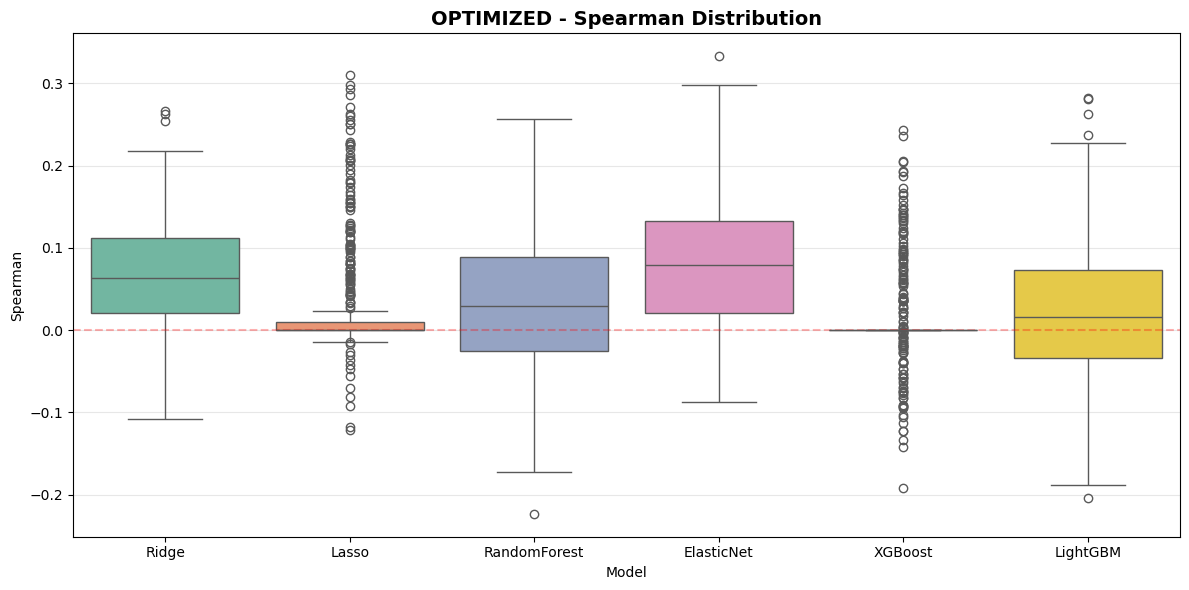

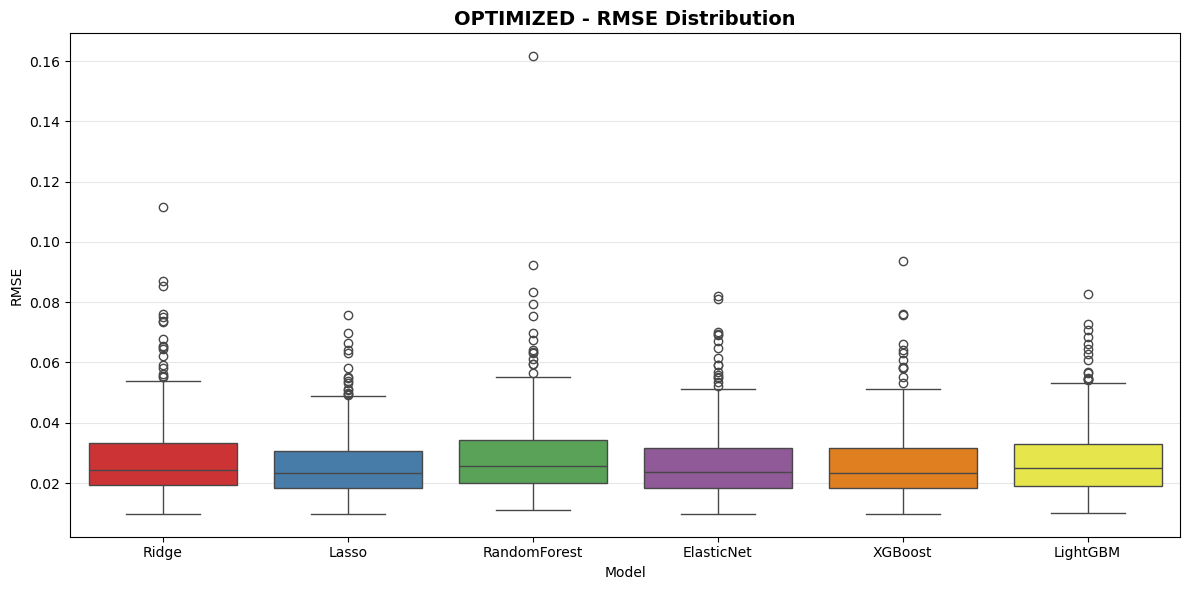

<Figure size 1400x600 with 0 Axes>

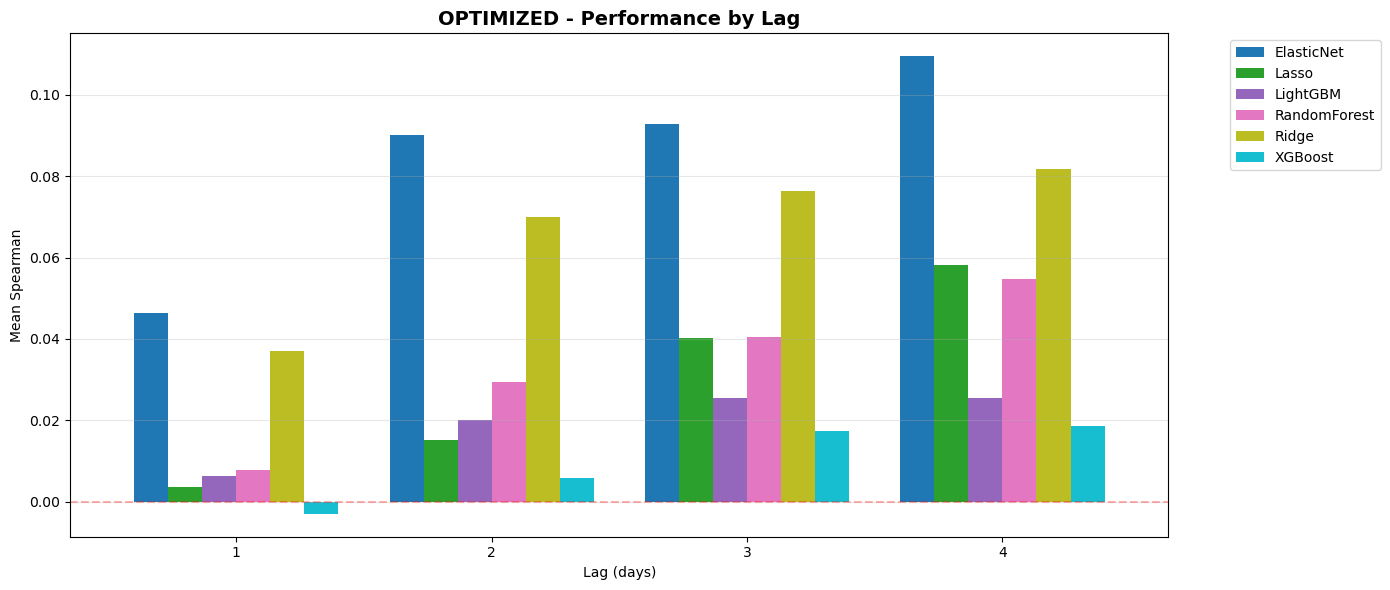

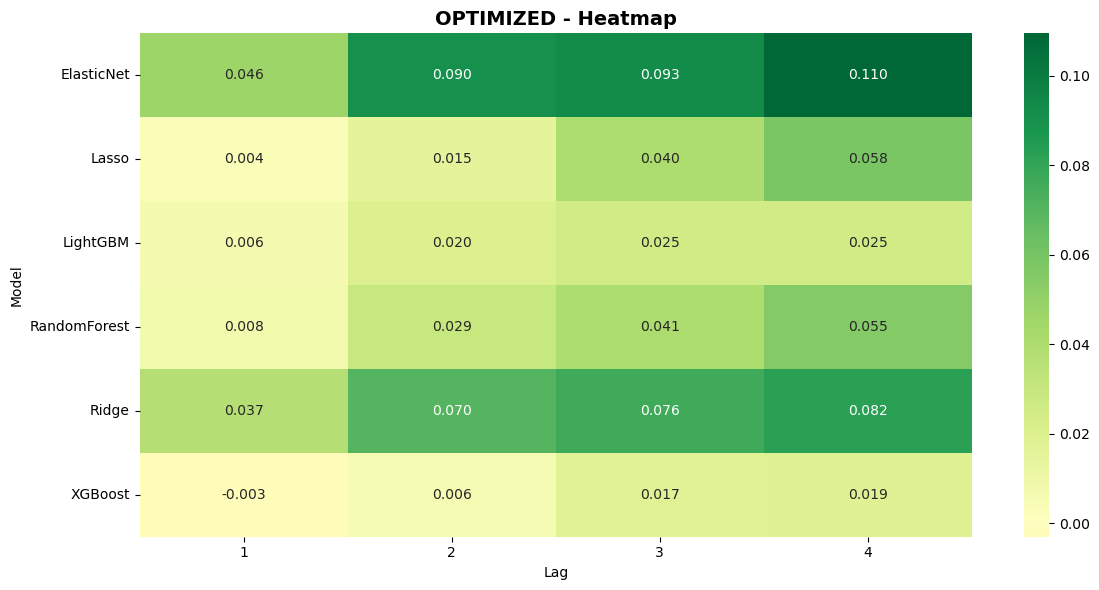


 OPTIMIZED FINAL STATS
Total Evaluations: 2528
Unique Targets: 424

 Best: ElasticNet | Spearman: 0.3329

 Mean by Model:
  ElasticNet     : 0.0847
  Ridge          : 0.0664
  RandomForest   : 0.0331
  Lasso          : 0.0293
  LightGBM       : 0.0193
  XGBoost        : 0.0097

 Files saved with prefix: optimized_


In [ ]:

if results:
    res_df = pd.DataFrame(results)
    
 
    results_file = f'{OUTPUT_PREFIX}results.csv'
    res_df.to_csv(results_file, index=False)
    print(f"\n Saved: {results_file}")
    
   
    if RUN_MODE == "OPTIMIZED" and best_params:
        with open('best_hyperparameters.json', 'w') as f:
            json.dump(best_params, f, indent=4)
        print(f" Saved: best_hyperparameters.json")
        
        if optimization_log:
            opt_df = pd.DataFrame(optimization_log)
            opt_df.to_csv(f'{OUTPUT_PREFIX}optimization_log.csv', index=False)
            print(f" Saved: {OUTPUT_PREFIX}optimization_log.csv")
    
  
    print("\n" + "="*60)
    print(f" {RUN_MODE} RUN SUMMARY")
    print("="*60)
    summary = res_df.groupby('Model').agg({
        'RMSE': ['mean', 'std', 'min', 'max'],
        'Spearman': ['mean', 'std', 'min', 'max'],
        'Train_Time': ['mean', 'sum']
    }).round(4)
    display(summary)
    summary.to_csv(f'{OUTPUT_PREFIX}summary.csv')
    

    print("\n" + "="*60)
    print(" PERFORMANCE BY LAG")
    print("="*60)
    lag_summary = res_df.groupby(['Lag', 'Model'])['Spearman'].mean().unstack().round(4)
    display(lag_summary)
    lag_summary.to_csv(f'{OUTPUT_PREFIX}lag_performance.csv')
    

    print("\n TOP 5 BEST:")
    display(res_df.nlargest(5, 'Spearman')[['Target', 'Pair', 'Model', 'RMSE', 'Spearman']])
    
    print("\n  TOP 5 WORST:")
    display(res_df.nsmallest(5, 'Spearman')[['Target', 'Pair', 'Model', 'RMSE', 'Spearman']])
    
 
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=res_df, x='Model', y='Spearman', palette='Set2')
    plt.title(f'{RUN_MODE} - Spearman Distribution', fontsize=14, fontweight='bold')
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.3)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_PREFIX}spearman.png', dpi=300, bbox_inches='tight')
    plt.show()
    
   
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=res_df, x='Model', y='RMSE', palette='Set1')
    plt.title(f'{RUN_MODE} - RMSE Distribution', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_PREFIX}rmse.png', dpi=300, bbox_inches='tight')
    plt.show()
    
  
    plt.figure(figsize=(14, 6))
    lag_perf = res_df.groupby(['Lag', 'Model'])['Spearman'].mean().unstack()
    lag_perf.plot(kind='bar', width=0.8, figsize=(14, 6), colormap='tab10')
    plt.title(f'{RUN_MODE} - Performance by Lag', fontsize=14, fontweight='bold')
    plt.xlabel('Lag (days)')
    plt.ylabel('Mean Spearman')
    plt.legend(bbox_to_anchor=(1.05, 1))
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.3)
    plt.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_PREFIX}lag_perf.png', dpi=300, bbox_inches='tight')
    plt.show()
    
 
    plt.figure(figsize=(12, 6))
    pivot = res_df.pivot_table(values='Spearman', index='Model', columns='Lag', aggfunc='mean')
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', center=0)
    plt.title(f'{RUN_MODE} - Heatmap', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_PREFIX}heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
 
    print("\n" + "="*60)
    print(f" {RUN_MODE} FINAL STATS")
    print("="*60)
    print(f"Total Evaluations: {len(res_df)}")
    print(f"Unique Targets: {res_df['Target'].nunique()}")
    best_row = res_df.loc[res_df['Spearman'].idxmax()]
    print(f"\n Best: {best_row['Model']} | Spearman: {best_row['Spearman']:.4f}")
    print(f"\n Mean by Model:")
    for model, score in res_df.groupby('Model')['Spearman'].mean().sort_values(ascending=False).items():
        print(f"  {model:15s}: {score:.4f}")
    
    print(f"\n Files saved with prefix: {OUTPUT_PREFIX}")

else:
    print(" No results!")

 BASELINE vs OPTIMIZED COMPARISON


,Baseline_Spearman,Baseline_Std,Optimized_Spearman,Optimized_Std,Baseline_RMSE,Optimized_RMSE,Spearman_Improvement_%,RMSE_Improvement_%
Model,,,,,,,,
ElasticNet,0.0642,0.0872,0.0847,0.0769,0.0256,0.0264,32.0625,-3.0910
Lasso,0.0293,0.0682,0.0293,0.0682,0.0256,0.0256,-0.0018,0.0000
LightGBM,0.0100,0.0797,0.0193,0.0782,0.0295,0.0273,92.4689,7.5289
RandomForest,0.0328,0.0800,0.0331,0.0799,0.0287,0.0287,1.1611,0.0063
Ridge,0.0664,0.0665,0.0664,0.0665,0.0280,0.0280,0.0000,-0.0000
XGBoost,0.0181,0.0701,0.0097,0.0531,0.0299,0.0261,-46.3682,12.7412


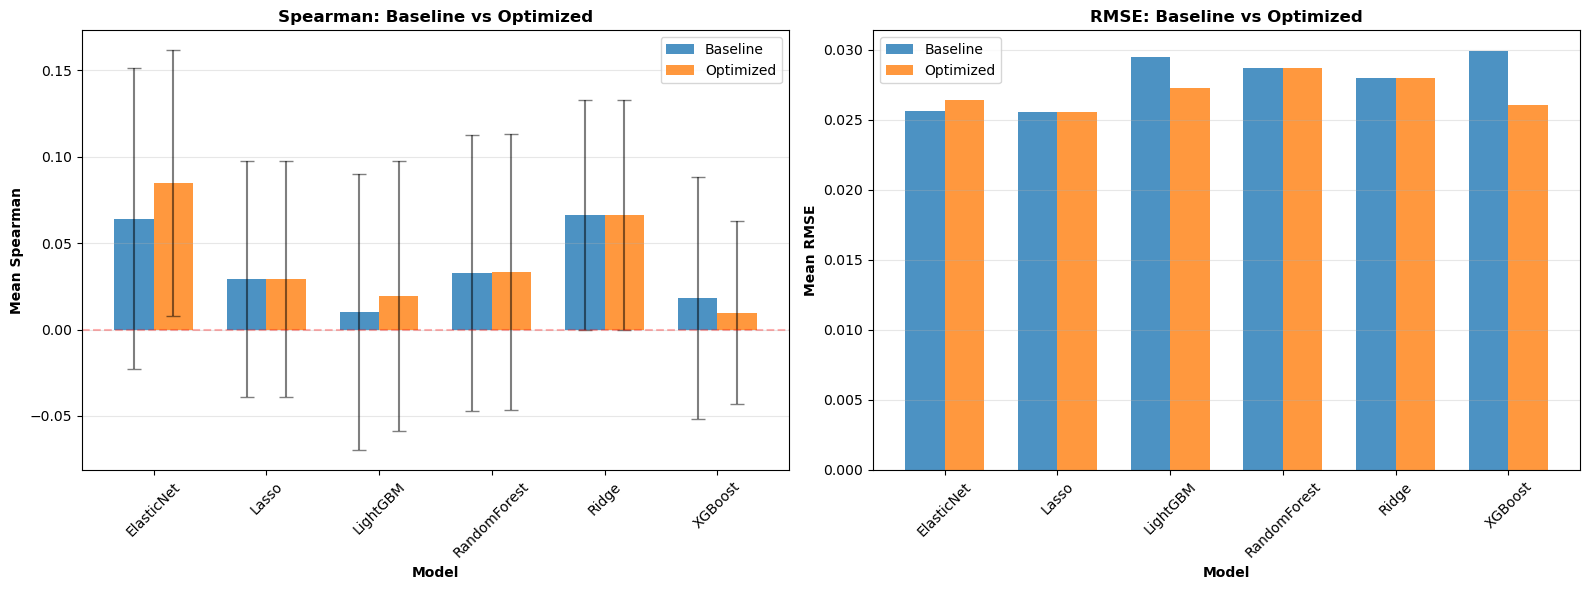

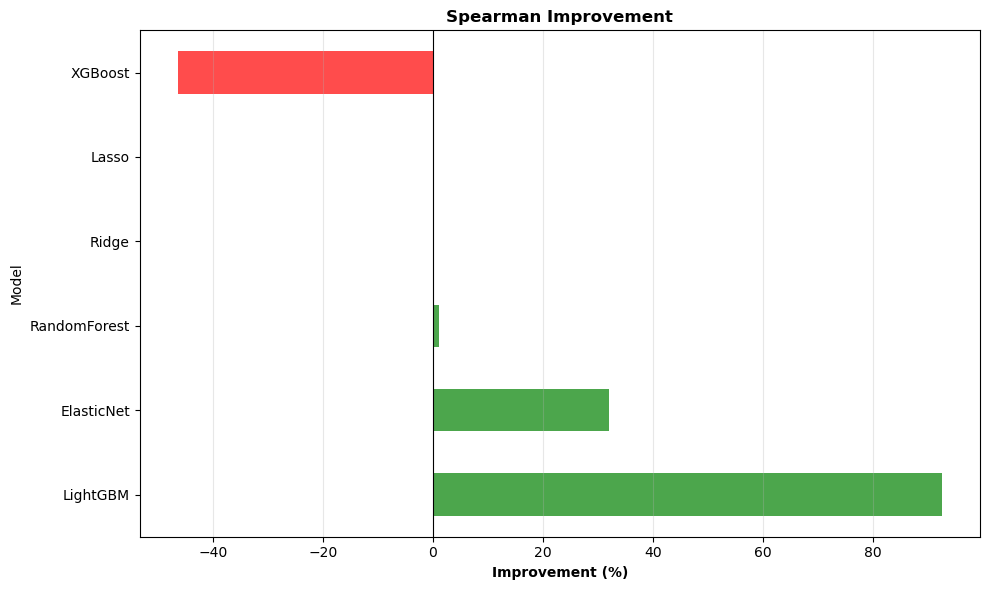


 COMPARISON COMPLETE!
Mean Improvement: 13.22%
  ElasticNet     : +32.06%
  Lasso          : -0.00%
  LightGBM       : +92.47%
  RandomForest   : +1.16%
  Ridge          : +0.00%
  XGBoost        : -46.37%


In [ ]:

try:
    baseline_df = pd.read_csv('baseline_results.csv')
    optimized_df = pd.read_csv('optimized_results.csv')
    
    print("="*60)
    print(" BASELINE vs OPTIMIZED COMPARISON")
    print("="*60)
    
    comparison = pd.DataFrame({
        'Baseline_Spearman': baseline_df.groupby('Model')['Spearman'].mean(),
        'Baseline_Std': baseline_df.groupby('Model')['Spearman'].std(),
        'Optimized_Spearman': optimized_df.groupby('Model')['Spearman'].mean(),
        'Optimized_Std': optimized_df.groupby('Model')['Spearman'].std(),
        'Baseline_RMSE': baseline_df.groupby('Model')['RMSE'].mean(),
        'Optimized_RMSE': optimized_df.groupby('Model')['RMSE'].mean()
    })
    
    comparison['Spearman_Improvement_%'] = (
        (comparison['Optimized_Spearman'] - comparison['Baseline_Spearman']) / 
        comparison['Baseline_Spearman'].abs() * 100
    )
    
    comparison['RMSE_Improvement_%'] = (
        (comparison['Baseline_RMSE'] - comparison['Optimized_RMSE']) / 
        comparison['Baseline_RMSE'] * 100
    )
    
    display(comparison.round(4))
    comparison.to_csv('comparison_summary.csv')
    
  
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    x = np.arange(len(comparison))
    width = 0.35
    

    ax1 = axes[0]
    ax1.bar(x - width/2, comparison['Baseline_Spearman'], width, label='Baseline', alpha=0.8)
    ax1.bar(x + width/2, comparison['Optimized_Spearman'], width, label='Optimized', alpha=0.8)
    ax1.errorbar(x - width/2, comparison['Baseline_Spearman'], yerr=comparison['Baseline_Std'], 
                 fmt='none', ecolor='black', capsize=5, alpha=0.5)
    ax1.errorbar(x + width/2, comparison['Optimized_Spearman'], yerr=comparison['Optimized_Std'], 
                 fmt='none', ecolor='black', capsize=5, alpha=0.5)
    ax1.set_xlabel('Model', fontweight='bold')
    ax1.set_ylabel('Mean Spearman', fontweight='bold')
    ax1.set_title('Spearman: Baseline vs Optimized', fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(comparison.index, rotation=45)
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    ax1.axhline(y=0, color='red', linestyle='--', alpha=0.3)
    

    ax2 = axes[1]
    ax2.bar(x - width/2, comparison['Baseline_RMSE'], width, label='Baseline', alpha=0.8)
    ax2.bar(x + width/2, comparison['Optimized_RMSE'], width, label='Optimized', alpha=0.8)
    ax2.set_xlabel('Model', fontweight='bold')
    ax2.set_ylabel('Mean RMSE', fontweight='bold')
    ax2.set_title('RMSE: Baseline vs Optimized', fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(comparison.index, rotation=45)
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    

    fig, ax = plt.subplots(figsize=(10, 6))
    improvements = comparison['Spearman_Improvement_%'].sort_values(ascending=False)
    colors = ['green' if x > 0 else 'red' for x in improvements]
    improvements.plot(kind='barh', color=colors, alpha=0.7, ax=ax)
    ax.set_xlabel('Improvement (%)', fontweight='bold')
    ax.set_title('Spearman Improvement', fontweight='bold')
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('improvement.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n COMPARISON COMPLETE!")
    print(f"Mean Improvement: {comparison['Spearman_Improvement_%'].mean():.2f}%")
    
    for model in comparison.index:
        spear = comparison.loc[model, 'Spearman_Improvement_%']
        print(f"  {model:15s}: {spear:+.2f}%")
    
except FileNotFoundError as e:
    print(f" {e}")
    print("Run both BASELINE and OPTIMIZED first!")